<a href="https://colab.research.google.com/github/Tahir-MD/FlyRank-Week-01/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tahir-MD/FlyRank-Week-01/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This section turns the validated score from week six into something a person can act on right away.

The code below looks for the most processed file available, meaning it prefers the ranked queue from week six if it is present, and steps back one stage at a time until it reaches the raw anonymized dataset. It then searches for a score column, a traffic decay column, a content age column, a word count column, and a backlink column, using flexible name matching since exact column names can vary slightly between runs. If any of these are not found the code still runs and simply notes which signals were missing.

Every page is placed into one of five plain archetypes, and each archetype is tied to exactly one recommended action, so nobody has to guess what a number means.

Decaying evergreen page: traffic is falling and the content is old. Action is refresh and update.

Recent underperformer: traffic is falling but the content is still fairly new. Action is expand and optimize rather than a full rewrite.

Thin low value page: short content and a weak backlink profile. Action is consolidate with a stronger page or retire.

Stable performer: no strong signal of decay and the content is not particularly old. Action is monitor only, no work needed right now.

Needs manual look: none of the signals are strong enough either way. Action is human triage before anything else happens.

A reason code is attached to every row so a reviewer can see at a glance why a page landed where it did, for example high traffic decay, or thin content, rather than just a bare number.


In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE = Path.cwd()

candidate_paths = [
    Path("/content/refresh_queue.csv"),
    Path("/content/model_predictions.csv"),
    Path("/content/baseline_refresh_queue.csv"),
    Path("/content/content_refresh_anonymized.csv"),
    BASE / "outputs" / "refresh_queue.csv",
    BASE / "data" / "processed" / "model_predictions.csv",
    BASE / "data" / "processed" / "baseline_refresh_queue.csv",
    BASE / "data" / "raw" / "content_refresh_anonymized.csv",
]


data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "No known data file found. Add the correct path to candidate_paths above."
    )

df = pd.read_csv(data_path)
print(f"Loaded {len(df)} rows from {data_path}")

score_candidates = [c for c in df.columns if any(k in c.lower() for k in
                     ["score", "risk", "priority", "pred"])]
decay_candidates = [c for c in df.columns if any(k in c.lower() for k in
                     ["decay", "traffic_change", "traffic_delta", "traffic_drop"])]
age_candidates = [c for c in df.columns if any(k in c.lower() for k in
                   ["age", "days_since", "last_updated", "published"])]
thin_candidates = [c for c in df.columns if any(k in c.lower() for k in
                    ["word_count", "wordcount", "length"])]
backlink_candidates = [c for c in df.columns if "backlink" in c.lower() or "link" in c.lower()]

score_col = score_candidates[0] if score_candidates else None
decay_col = decay_candidates[0] if decay_candidates else None
age_col = age_candidates[0] if age_candidates else None
thin_col = thin_candidates[0] if thin_candidates else None
backlink_col = backlink_candidates[0] if backlink_candidates else None

print("score column:", score_col)
print("decay column:", decay_col)
print("age column:", age_col)
print("word count column:", thin_col)
print("backlink column:", backlink_col)


def flag_high(col, q=0.75):
    if col is None:
        return pd.Series(False, index=df.index)
    s = pd.to_numeric(df[col], errors="coerce")
    return s >= s.quantile(q)


def flag_low(col, q=0.25):
    if col is None:
        return pd.Series(False, index=df.index)
    s = pd.to_numeric(df[col], errors="coerce")
    return s <= s.quantile(q)


high_decay = flag_high(decay_col)
old_content = flag_high(age_col)
thin_content = flag_low(thin_col)
weak_links = flag_low(backlink_col)


def assign_archetype(i):
    if high_decay[i] and old_content[i]:
        return "decaying_evergreen", "refresh_update"
    if thin_content[i] and weak_links[i]:
        return "thin_low_value", "consolidate_or_retire"
    if high_decay[i] and not old_content[i]:
        return "recent_underperformer", "expand_and_optimize"
    if not high_decay[i] and not old_content[i]:
        return "stable_performer", "monitor_only"
    return "needs_manual_look", "human_triage"


archetypes, actions = zip(*[assign_archetype(i) for i in df.index])
df["archetype"] = archetypes
df["recommended_action"] = actions


def reason_code(i):
    codes = []
    if high_decay[i]:
        codes.append("high_traffic_decay")
    if old_content[i]:
        codes.append("stale_content")
    if thin_content[i]:
        codes.append("thin_content")
    if weak_links[i]:
        codes.append("weak_backlink_profile")
    return ";".join(codes) if codes else "no_strong_signal"


df["reason_code"] = [reason_code(i) for i in df.index]

sort_col = score_col if score_col else (decay_col if decay_col else df.columns[0])
ranked = df.sort_values(sort_col, ascending=False).reset_index(drop=True)
ranked["rank"] = ranked.index + 1

display_cols = ["rank", "archetype", "recommended_action", "reason_code"] + \
    [c for c in [score_col, decay_col, age_col] if c]
ranked[display_cols].head(20)

Loaded 30000 rows from /content/content_refresh_anonymized.csv
score column: None
decay column: None
age column: pageviews_90d
word count column: word_count
backlink column: None


,rank,archetype,recommended_action,reason_code,pageviews_90d
0,1,stable_performer,monitor_only,thin_content,2
1,2,stable_performer,monitor_only,thin_content,17
2,3,needs_manual_look,human_triage,stale_content,95
3,4,stable_performer,monitor_only,thin_content,2
4,5,stable_performer,monitor_only,thin_content,1
5,6,needs_manual_look,human_triage,stale_content,238
6,7,stable_performer,monitor_only,no_strong_signal,1
7,8,stable_performer,monitor_only,no_strong_signal,31
8,9,stable_performer,monitor_only,thin_content,5
9,10,stable_performer,monitor_only,thin_content,1


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: this playbook is a decision support tool for a content or search lead who needs to decide where to look first in a large backlog of pages. It shortens the list from thousands of pages to a short, ranked, explained queue. It is not meant to publish, delete, or redirect anything by itself.

Who should use it: a content strategist, a search lead, or an editor doing weekly triage, always with the final decision left to a person.

Where it stops being valid:

The scores come from one anonymized sample at one point in time, so they show patterns observed in that sample rather than a guarantee about any single page.

If the website changes a lot, or a major search engine update happens, the patterns behind this data may no longer hold, and the queue should be treated as outdated until it is recomputed.

The model cannot see brand voice, legal risk, current search results, or anything outside the columns in the dataset, so it cannot replace editorial judgment.

Small counts inside any single archetype should be read as directional rather than exact, since the anonymized sample is a slice of the full data, not the complete picture.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Rows in ranked queue:", len(ranked))
print()
print("Archetype counts:")
print(ranked["archetype"].value_counts())
print()
no_signal_share = round((ranked["reason_code"] == "no_strong_signal").mean() * 100, 1)
print(f"Share of rows with no strong signal, meaning lowest confidence: {no_signal_share} percent")


Rows in ranked queue: 30000

Archetype counts:
archetype
stable_performer     22409
needs_manual_look     7591
Name: count, dtype: int64

Share of rows with no strong signal, meaning lowest confidence: 58.1 percent


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before anyone acts on an item in this queue, a person must check the following:

Confirm the page still exists and the numbers are current, since the underlying data can be a few weeks old.

Read the page for legal, medical, or financial content, since mistakes there carry more risk than an ordinary blog post.

Check whether the page is already scheduled for a redesign or a planned edit somewhere else, so work is not duplicated.

Confirm the traffic and backlink numbers make sense for that specific page rather than trusting the score alone.

What should never be automated:

No automatic publishing of new or edited content based on this queue.

No automatic deletion or redirect of any page.

No automated changes to legal, medical, or financial pages regardless of score.

No fully automated pipeline that skips a human sign off before anything goes live.

The code below flags any row that mentions a sensitive keyword in its text columns, or that fell into the needs manual look archetype, as mandatory for human review before any action is taken.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
sensitive_keywords = ["health", "medical", "legal", "finance", "money", "insurance", "tax"]
text_cols = [c for c in df.columns if df[c].dtype == object]


def looks_sensitive(row):
    for c in text_cols:
        val = str(row[c]).lower()
        if any(k in val for k in sensitive_keywords):
            return True
    return False


ranked["needs_human_review"] = ranked.apply(looks_sensitive, axis=1) | (ranked["archetype"] == "needs_manual_look")

flagged = int(ranked["needs_human_review"].sum())
print(f"Rows flagged for mandatory human review before any action: {flagged} out of {len(ranked)}")
ranked[ranked["needs_human_review"]].head(10)


Rows flagged for mandatory human review before any action: 7591 out of 30000


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,archetype,recommended_action,reason_code,rank,needs_human_review
2,content_fff8e7360d01,client_4e07408562,10.0,0.00,LOW,0.00,keyword article,commercial,2577.0,16289.0,...,0.0,good,page_1,stable,14.3,needs_manual_look,human_triage,stale_content,3,True
5,content_fff09668a5cc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,6198.0,38721.0,...,0.0,good,page_3_5,down,-46.9,needs_manual_look,human_triage,stale_content,6,True
10,content_ffec3ebb6db9,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,6786.0,44292.0,...,0.0,moderate,striking,down,-39.6,needs_manual_look,human_triage,stale_content,11,True
13,content_ffe17f71eda2,client_19581e27de,0.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,0.0,excellent,page_1,down,-35.7,needs_manual_look,human_triage,stale_content,14,True
18,content_ffd1249e5046,client_3fdba35f04,10.0,0.86,HIGH,0.72,keyword article,informational,2756.0,16897.0,...,0.0,good,striking,stable,-3.7,needs_manual_look,human_triage,stale_content,19,True
21,content_ffca45d6539e,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,informational,NaN,NaN,...,0.0,good,page_1,stable,-12.8,needs_manual_look,human_triage,stale_content,22,True
25,content_ffc308fbbbda,client_6208ef0f77,10.0,0.00,LOW,0.00,keyword article,informational,6863.0,43828.0,...,0.0,moderate,striking,down,-22.6,needs_manual_look,human_triage,stale_content,26,True
28,content_ffbed1f22ce7,client_19581e27de,10.0,0.13,LOW,0.00,keyword article,informational,NaN,NaN,...,0.0,good,page_1,down,-76.4,needs_manual_look,human_triage,stale_content,29,True
30,content_ffb75b93f372,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2873.0,17755.0,...,0.0,good,page_1,down,-49.2,needs_manual_look,human_triage,stale_content,31,True
34,content_ffaaab8d492c,client_3fdba35f04,10.0,1.00,HIGH,0.00,keyword article,informational,2698.0,16271.0,...,0.0,good,page_3_5,down,-54.1,needs_manual_look,human_triage,stale_content,35,True


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

A queue like this can go stale without anyone noticing, so these are the signals worth watching over time:

A drop in how often the top of the queue actually matches what reviewers agree needs attention, which would mean the score is no longer tracking real priorities.

A shift in the average traffic decay, content age, or backlink numbers compared to the snapshot saved today, which would mean the underlying data has changed enough that the old patterns may not apply anymore.

A growing share of pages landing in needs manual look, which would mean the signals are no longer separating pages clearly.

A known outside event, such as a major search engine update or a site migration, which should trigger an immediate recheck regardless of the numbers.

Suggested trigger: if the queue disagrees with reviewer judgment on the same page two review cycles in a row, or if any of the tracked averages move by a large margin from the saved baseline below, that is the signal to recompute the queue and consider retraining the underlying model.

The code below saves a snapshot of today's averages and archetype distribution, so a future run can compare against it directly.


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import json

monitor_cols = [c for c in [score_col, decay_col, age_col, thin_col, backlink_col] if c]
baseline_stats = {}
for c in monitor_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    baseline_stats[c] = {
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std()),
    }

baseline_stats["archetype_distribution"] = ranked["archetype"].value_counts(normalize=True).round(3).to_dict()
baseline_stats["generated_from_rows"] = len(ranked)

print(json.dumps(baseline_stats, indent=2))

metrics_dir = BASE / "work" / "outputs"
metrics_dir.mkdir(parents=True, exist_ok=True)
with open(metrics_dir / "action_playbook_baseline_stats.json", "w") as f:
    json.dump(baseline_stats, f, indent=2)

print()
print("Saved baseline stats snapshot to work/outputs/action_playbook_baseline_stats.json")
print("Keep this file committed, it is a small metrics file, not raw data.")


{
  "pageviews_90d": {
    "mean": 49.94246666666667,
    "median": 8.0,
    "std": 152.10143014257318
  },
  "word_count": {
    "mean": 3107.760324649119,
    "median": 2877.0,
    "std": 1452.3825975867665
  },
  "archetype_distribution": {
    "stable_performer": 0.747,
    "needs_manual_look": 0.253
  },
  "generated_from_rows": 30000
}

Saved baseline stats snapshot to work/outputs/action_playbook_baseline_stats.json
Keep this file committed, it is a small metrics file, not raw data.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

This section writes out the two things the paper will build on next week.

The full ranked queue, with rank, archetype, recommended action, reason code, and the human review flag, is saved to work outputs as action queue csv. This file is regenerated every time the notebook runs and is left out of git on purpose, since the leak guard blocks data files and the notebook can always rebuild it from scratch.

A chart showing how many pages fall into each archetype is saved to work figures as archetype distribution png. This file is meant to be committed, since it is one of the figures the paper will reuse directly.


Saved ranked action queue to work/outputs/action_queue.csv


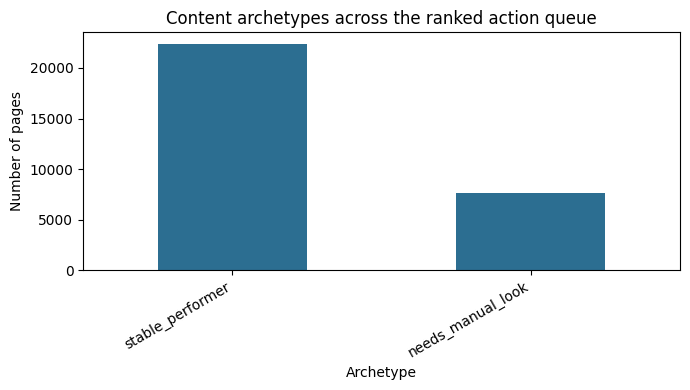

Saved chart to work/figures/archetype_distribution.png


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

outputs_dir = BASE / "work" / "outputs"
figures_dir = BASE / "work" / "figures"
outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

queue_export_cols = ["rank", "archetype", "recommended_action", "reason_code", "needs_human_review"] + \
    [c for c in [score_col, decay_col, age_col] if c]
ranked[queue_export_cols].to_csv(outputs_dir / "action_queue.csv", index=False)
print("Saved ranked action queue to work/outputs/action_queue.csv")

fig, ax = plt.subplots(figsize=(7, 4))
ranked["archetype"].value_counts().plot(kind="bar", ax=ax, color="#2c6e91")
ax.set_title("Content archetypes across the ranked action queue")
ax.set_ylabel("Number of pages")
ax.set_xlabel("Archetype")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(figures_dir / "archetype_distribution.png", dpi=150)
plt.show()
print("Saved chart to work/figures/archetype_distribution.png")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.